## MIMIC-CXR EDA
This notebook contains an Exploratory Data Analysis of MIMIC-CXR dataset 

### Imports

In [1]:
import pandas as pd

### Survey available data

In [2]:
import os


'/clusteruy/home/jplago/mcdaa-thesis/notebooks'

In [11]:
chexpert_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/mimic-cxr-2.0.0-chexpert.csv'
metadata_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/mimic-cxr-2.0.0-metadata.csv'
negbio_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/mimic-cxr-2.0.0-negbio.csv'
manual_test_labels_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/mimic-cxr-2.1.0-test-set-labeled.csv'

chexpert_ds = pd.read_csv(chexpert_path)
metadata_ds = pd.read_csv(metadata_path)
negbio_ds = pd.read_csv(negbio_path)
manual_test_labels_ds = pd.read_csv(manual_test_labels_path)

provider_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/cxr-provider-list.csv'
study_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/cxr-study-list.csv'
records_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/cxr-record-list.csv'

provider_ds = pd.read_csv(provider_path)
study_ds = pd.read_csv(study_path)
records_ds = pd.read_csv(records_path)

In [12]:
chexpert_ds = chexpert_ds.set_index('study_id', drop=True)

In [ ]:
chexpert_ds

,subject_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
study_id,,,,,,,,,,,,,,,
50414267,10000032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
53189527,10000032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
53911762,10000032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
56699142,10000032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
57375967,10000764,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58708861,19999442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57132437,19999733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
55368167,19999987,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


Contains Chexpert labelings. 

In [7]:
metadata_ds

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
377105,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,19999733,57132437,CHEST (PA AND LAT),PA,3056,2544,21520708,224550.171,CHEST (PA AND LAT),postero-anterior,Erect
377106,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9,19999733,57132437,CHEST (PA AND LAT),LATERAL,3056,2544,21520708,224550.171,CHEST (PA AND LAT),lateral,Erect
377107,58766883-376a15ce-3b323a28-6af950a0-16b793bd,19999987,55368167,CHEST (PORTABLE AP),AP,2544,3056,21451104,51448.218,CHEST (PORTABLE AP),antero-posterior,Erect
377108,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,19999987,58621812,CHEST (PORTABLE AP),AP,3056,2544,21451102,202809.234,CHEST (PORTABLE AP),antero-posterior,Erect


Relevant information for every image, such as resolution, view position, and performed procedures for a patient.

In [9]:
negbio_ds

,subject_id,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10000032,50414267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,10000032,53189527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
2,10000032,53911762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
3,10000032,56699142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,10000764,57375967,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227822,19999442,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
227823,19999733,57132437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
227824,19999987,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN
227825,19999987,58621812,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


Same categorization as chexpert ds, probably different procedure.

In [11]:
manual_test_labels_ds

,study_id,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Lesion,Airspace Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,58085167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,57798090,NaN,1.0,1.0,NaN,NaN,0.0,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN
2,50020371,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52225063,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,59039129,NaN,NaN,1.0,NaN,1.0,-1.0,-1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,53953586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
683,59358922,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
684,53225437,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN
685,56814609,NaN,NaN,1.0,0.0,NaN,0.0,NaN,NaN,0.0,NaN,0.0,1.0,NaN,NaN


Manually curated labels for 687 patients.

In [13]:
provider_ds

,study_id,ordering_provider_id,attending_provider_id,resident_provider_id
0,50000014,P14F76,P18MMU,P86T8X
1,50000028,P491T2,P44ODT,P95V30
2,50000052,P93MI7,P40NZ1,NaN
3,50000103,P03X7D,P4302T,P33HA3
4,50000125,P38LAS,P035IN,NaN
...,...,...,...,...
227830,59999832,P23Y5G,P48R96,NaN
227831,59999849,P7554I,P035IN,NaN
227832,59999880,P885Z8,P26C49,NaN
227833,59999888,P418IO,P48R96,NaN


Irrelevant

In [ ]:
study_ds

,subject_id,study_id,path
0,10000032,50414267,files/p10/p10000032/s50414267.txt
1,10000032,53189527,files/p10/p10000032/s53189527.txt
2,10000032,53911762,files/p10/p10000032/s53911762.txt
3,10000032,56699142,files/p10/p10000032/s56699142.txt
4,10000764,57375967,files/p10/p10000764/s57375967.txt
...,...,...,...
227830,19999442,58708861,files/p19/p19999442/s58708861.txt
227831,19999733,57132437,files/p19/p19999733/s57132437.txt
227832,19999987,55368167,files/p19/p19999987/s55368167.txt
227833,19999987,58621812,files/p19/p19999987/s58621812.txt


Paths to the reports for every study.

In [18]:
study_ds.study_id.nunique()

227835

In [21]:
records_ds

,subject_id,study_id,dicom_id,path
0,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267/02aa804e-bde0afd...
1,10000032,50414267,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,files/p10/p10000032/s50414267/174413ec-4ec4c1f...
2,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527/2a2277a9-b0ded15...
3,10000032,53189527,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,files/p10/p10000032/s53189527/e084de3b-be89b11...
4,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762/68b5c4b1-227d048...
...,...,...,...,...
377105,19999733,57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437/428e2c18-5721d8f...
377106,19999733,57132437,58c403aa-35ff8bd9-73e39f54-8dc9cc5d-e0ec3fa9,files/p19/p19999733/s57132437/58c403aa-35ff8bd...
377107,19999987,55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167/58766883-376a15c...
377108,19999987,58621812,7ba273af-3d290f8d-e28d0ab4-484b7a86-7fc12b08,files/p19/p19999987/s58621812/7ba273af-3d290f8...


Paths to every image. Contains batch information.

### Studies ds

In [13]:
studies = study_ds.copy()
studies = studies.set_index('study_id', drop= True)
studies['batch'] = studies.path.apply(lambda x: x.split('/')[1])
studies

,subject_id,path,batch
study_id,,,
50414267,10000032,files/p10/p10000032/s50414267.txt,p10
53189527,10000032,files/p10/p10000032/s53189527.txt,p10
53911762,10000032,files/p10/p10000032/s53911762.txt,p10
56699142,10000032,files/p10/p10000032/s56699142.txt,p10
57375967,10000764,files/p10/p10000764/s57375967.txt,p10
...,...,...,...
58708861,19999442,files/p19/p19999442/s58708861.txt,p19
57132437,19999733,files/p19/p19999733/s57132437.txt,p19
55368167,19999987,files/p19/p19999987/s55368167.txt,p19


In [70]:
studies.batch.value_counts().sort_index()

batch
p10    22197
p11    23358
p12    22428
p13    22945
p14    22589
p15    23713
p16    22151
p17    22695
p18    22929
p19    22830
Name: count, dtype: int64

In [71]:
p19 = studies.query('batch == "p19"').copy()
len(p19)

22830

In [72]:
p19['report'] = ''
base_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/'
for ind, row in p19.iterrows():
    with open(os.path.join(base_path, row.path), 'r') as file:
        p19.at[ind, 'report'] = file.read()
    

### Manual labels analysis

In [15]:
manual_test_labels_ds = manual_test_labels_ds.join(studies[['batch']], on='study_id', how='left')
manual_test_labels_ds = manual_test_labels_ds.set_index('study_id', drop = True)
manual_test_labels_ds


,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Lesion,Airspace Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,batch
study_id,,,,,,,,,,,,,,,
58085167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,p18
57798090,NaN,1.0,1.0,NaN,NaN,0.0,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,p16
50020371,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,p15
52225063,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,p15
59039129,NaN,NaN,1.0,NaN,1.0,-1.0,-1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,p19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53953586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,p19
59358922,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,p12
53225437,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,NaN,p12


In [54]:
manual_test_labels_ds.batch.value_counts()

batch
p15    99
p19    90
p16    73
p13    71
p14    70
p11    68
p18    57
p17    56
p12    53
p10    48
Name: count, dtype: int64

There are 90 subjects from p19 that can be tested vs manual labels.

In [19]:
manual_test_labels_ds.query('batch == "p19"')['Atelectasis'].value_counts()

Atelectasis
 1.0    20
-1.0     4
Name: count, dtype: int64

In [24]:
manual_test_labels_ds.query('batch == "p19"')['Cardiomegaly'].value_counts()

Cardiomegaly
 1.0    16
 0.0    12
-1.0     5
Name: count, dtype: int64

### Chexpert labels validation

In [20]:
chexpert_ds.columns

Index(['subject_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [21]:
label_categories = ['Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']
def concatenate_non_nan(row):
    return ", ".join(f"{col}: {row[col]}" for col in row.index if (pd.notna(row[col]) and col in label_categories))


,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Lesion,Airspace Opacity,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,batch
study_id,,,,,,,,,,,,,,,
59039129,NaN,NaN,1.0,NaN,1.0,-1.0,-1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,p19
55775366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,p19
56630223,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,p19
56732549,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,p19
50916783,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,NaN,NaN,1.0,p19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59041431,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,p19
54621108,NaN,NaN,-1.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0.0,NaN,1.0,NaN,p19
51320163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,p19


In [22]:
manual_p19 = manual_test_labels_ds.query('batch == "p19"')
for _, row in manual_p19.sample(10).iterrows():
    print(f'Patient {_}')
    print(f'manual labels')
    print(concatenate_non_nan(manual_p19.loc[_]))
    print('chexpert labels')
    print(concatenate_non_nan(chexpert_ds.loc[_]))
    print(p19.loc[_, 'report'])
    print('\n\n')
     

Patient 59094609
manual labels
Edema: -1.0, Atelectasis: 1.0, Pleural Effusion: 1.0, Support Devices: 1.0
chexpert labels
Atelectasis: 1.0, Edema: 1.0, Pleural Effusion: 1.0, Support Devices: 1.0


NameError: name 'p19' is not defined

### Chexpert labels distribution 

In [7]:
five_categories = ['Atelectasis', 'Cardiomegaly','Edema', 'Pleural Effusion', 'Pneumothorax']
other_categories = ['Consolidation',  'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 
       'Pleural Other', 'Pneumonia', 'Support Devices']
for category in five_categories:
    print(chexpert_ds[category].value_counts())

Atelectasis
 1.0    45808
-1.0    10327
 0.0     1531
Name: count, dtype: int64
Cardiomegaly
 1.0    44845
 0.0    15911
-1.0     6043
Name: count, dtype: int64
Edema
 1.0    27018
 0.0    25641
-1.0    13174
Name: count, dtype: int64
Pleural Effusion
 1.0    54300
 0.0    27158
-1.0     5814
Name: count, dtype: int64
Pneumothorax
 0.0    42356
 1.0    10358
-1.0     1134
Name: count, dtype: int64


In [2]:
import os
data_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/p10'
all_patients = [f.path for f in os.scandir(data_path) if f.is_dir()]
print(len(all_patients))

5


### Create dataframe

In [ ]:
import os
import pandas as pd

# List to store extracted data
data = []

# Iterate over patient folders (e.g., p10000032)
for patient in os.listdir(data_path):
    patient_path = os.path.join(data_path, patient)
    
    if not os.path.isdir(patient_path):  # Skip files
        continue

    # Iterate over CXR study folders (e.g., s56699142)
    for cxr in os.listdir(patient_path):
        cxr_path = os.path.join(patient_path, cxr)

        if not os.path.isdir(cxr_path):  # Skip files
            continue

        # Get DICOM file (assumes only one per folder)
        dicom_files = [f for f in os.listdir(cxr_path) if f.endswith('.dcm')]
        dicom_file = dicom_files[0] if dicom_files else None

        # Get report file (assumes format 'cxr_folder.txt' exists in patient_path)
        report_path = os.path.join(patient_path, f"{cxr}.txt")
        report_content = open(report_path, 'r').read() if os.path.exists(report_path) else None

        # Append data to the list
        if dicom_file and report_content:
            data.append({
                "patient": patient,
                "cxr": cxr,
                "img_path": dicom_file,
                "report": report_content
            })

# Create DataFrame
df = pd.DataFrame(data)

# Display the first rows
display(df.head())

# Save as CSV if needed
#df.to_csv("cxr_data.csv", index=False)

,patient,cxr,img_path,report
0,p10000764,s57375967,b79e55c3-735ce5ac-64412506-cdc9ea79-f1af521f.dcm,FINAL REPORT\...
1,p10000980,s58636672,c7526473-7b7214ee-a5d58d12-29d1f67f-9f4edf00.dcm,FINAL REPORT\...
2,p10000980,s50985099,6ad03ed1-97ee17ee-9cf8b320-f7011003-cd93b42d.dcm,FINAL REPORT\...
3,p10000980,s54935705,8ffec5b7-419a7a3f-2bd64dc8-da23ed1e-24e1a884.dcm,FINAL REPORT\...
4,p10000980,s59988438,57a3c797-7272b246-fa226777-e4c7d84c-91ec2e96.dcm,FINAL REPORT\...


#### Report lengths

In [24]:
print(df.loc[0, 'report'])

                                 FINAL REPORT
 EXAMINATION:  CHEST (PA AND LAT)
 
 INDICATION:  ___M with hypoxia  // ?pna, aspiration.
 
 COMPARISON:  None
 
 FINDINGS: 
 
 PA and lateral views of the chest provided.   The lungs are adequately
 aerated.
 
 There is a focal consolidation at the left lung base adjacent to the lateral
 hemidiaphragm. There is mild vascular engorgement. There is bilateral apical
 pleural thickening.
 
 The cardiomediastinal silhouette is remarkable for aortic arch calcifications.
 The heart is top normal in size.
 
 IMPRESSION: 
 
 Focal consolidation at the left lung base, possibly representing aspiration or
 pneumonia.
 
 Central vascular engorgement.



In [ ]:
import pydicom
import cv2
import numpy as np

# Load the DICOM file
ds = pydicom.dcmread(dicom_path)

# Extract pixel data as a NumPy array
image_array = ds.pixel_array

# Get the original resolution
original_height, original_width = image_array.shape
print(f"Original Resolution: {original_width}x{original_height}")

# Normalize pixel values to 8-bit range (0-255) if needed
image_array = (image_array - image_array.min()) / (image_array.max() - image_array.min()) * 255
image_array = image_array.astype(np.uint8)

# Resize the image to 512x512
resized_image = cv2.resize(image_array, (512, 512), interpolation=cv2.INTER_AREA)

# Save as PNG
output_path = "temp/output.png"
cv2.imwrite(output_path, resized_image)

print(f"Saved resized image to {output_path}")

def show_img(path):
     

### Sample images and reports

In [18]:
import random
import os

n = 5
sample = random.sample(all_patients, n)

In [ ]:
for patient in sample:
    cxrs = [f.path for f in os.scandir(patient) if f.is_dir()]
    

In [5]:
import os

patient_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/p10/p10000032'
os.listdir(patient_path)

['s53189527.txt',
 'index.html',
 's56699142',
 's53189527',
 's53911762.txt',
 's50414267.txt',
 's53911762',
 's50414267',
 's56699142.txt']

In [6]:
one_cxr_folder = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/p10/p10000032/s56699142'
os.listdir(one_cxr_folder)

['index.html', 'ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.dcm']

### Read and save a dicom image to png 512x512

In [3]:
import pydicom
import cv2
import numpy as np

# Load the DICOM file
dicom_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/p10/p10000032/s56699142/ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.dcm'
ds = pydicom.dcmread(dicom_path)

# Extract pixel data as a NumPy array
image_array = ds.pixel_array

# Get the original resolution
original_height, original_width = image_array.shape
print(f"Original Resolution: {original_width}x{original_height}")

# Normalize pixel values to 8-bit range (0-255) if needed
image_array = (image_array - image_array.min()) / (image_array.max() - image_array.min()) * 255
image_array = image_array.astype(np.uint8)

# Resize the image to 512x512
resized_image = cv2.resize(image_array, (512, 512), interpolation=cv2.INTER_AREA)

# Save as PNG
output_path = "temp/output.png"
cv2.imwrite(output_path, resized_image)

print(f"Saved resized image to {output_path}")

Original Resolution: 2544x3056
Saved resized image to temp/output.png


Matplotlib is building the font cache; this may take a moment.


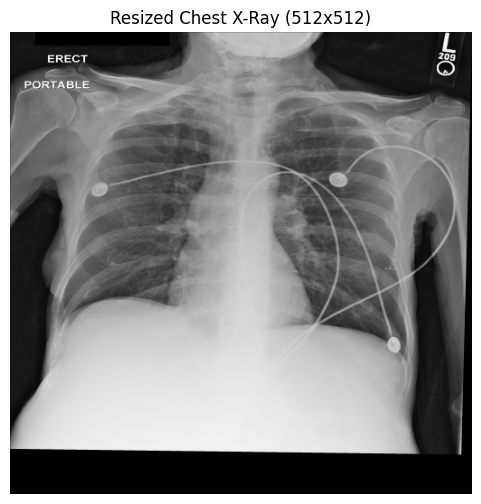

Saved resized image to temp/output.png


In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(resized_image, cmap='gray')  # Show in grayscale
plt.axis('off')  # Hide axes
plt.title("Resized Chest X-Ray (512x512)")
plt.show()

### Compare resized dicom to resized jpg

In [25]:
from PIL import Image

# Load the DICOM file
jpg_path = '/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s56699142/ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg'

image = Image.open(jpg_path)

# Get the original resolution
original_height, original_width = image.size
print(f"Original Resolution: {original_width}x{original_height}")

# Resize the image to 512x512
resized_image = image.resize((512, 512))

# Save as PNG
output_path = "temp/output_jpg.png"
resized_image.save(output_path)

print(f"Saved resized image to {output_path}")

Original Resolution: 3056x2544
Saved resized image to temp/output_jpg.png


In [30]:
def concat(images):
    # Get the total width and max height of the images
    total_width = sum(image.width for image in images)
    max_height = max(image.height for image in images)

    # Create a new blank image with the computed width and height
    new_image = Image.new('RGB', (total_width, max_height))

    # Paste each image into the new image
    current_width = 0
    for image in images:
        new_image.paste(image, (current_width, 0))
        current_width += image.width

    return new_image

def show_imgs(path, resolution = (512, 512)):
    imgs =  [Image.open(f.path).resize(resolution) for f in os.scandir(path) if f.name.endswith('jpg')]
    return concat(imgs)


resized jpg | resized dicom


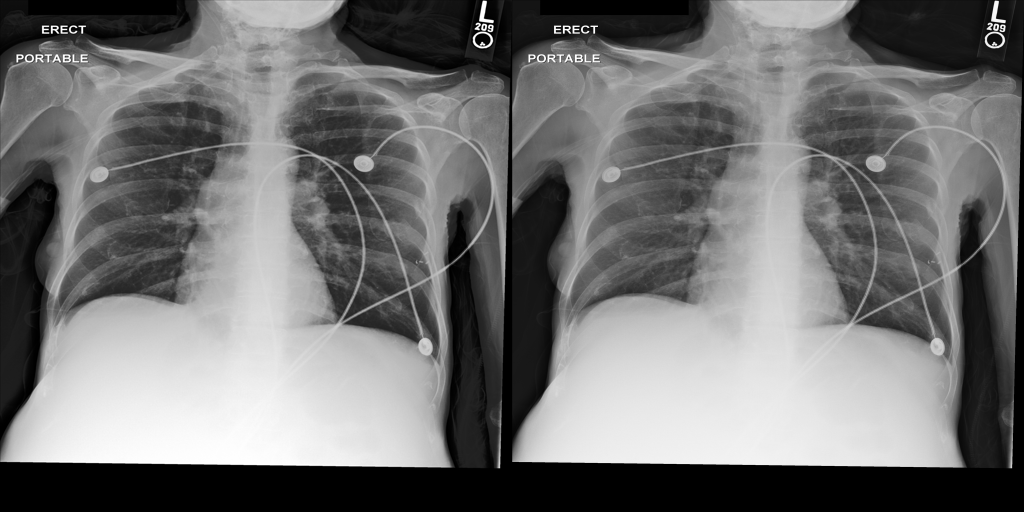

In [28]:
# Compare
imgs = []

imgs.append(Image.open("temp/output_jpg.png"))
imgs.append(Image.open("temp/output.png"))

print('resized jpg | resized dicom')
concat(imgs)



The resized jpg image shows a slightly better contrast. 
This is probably due to the processing conducted in converting dicom -> jpg.

(from https://physionet.org/content/mimic-cxr-jpg/2.1.0/#files-panel)
'Chest radiographs were converted from DICOM to a compressed JPG format. First, the image pixels were extracted from the DICOM file using the pydicom library [10]. Pixel values were normalized to the range [0, 255] by subtracting the lowest value in the image, dividing by the highest value in the shifted image, truncating values, and converting the result to an unsigned integer. The DICOM field PhotometricInterpretation was used to determine whether the pixel values were inverted, and if necessary images were inverted such that air in the image appears white (highest pixel value), while the outside of the patient's body appears black (lowest pixel value). The OpenCV library was then used to histogram equalize the image with the intention of enhancing contrast. Histogram equalization involves shifting pixel values towards 0 or towards 255 such that all pixel values 0 through 255 have approximately equal frequency. Images were then converted to JPG files using OpenCV with a quality factor of 95.'

### Visual Insights & Observations

#### Some images are rotated

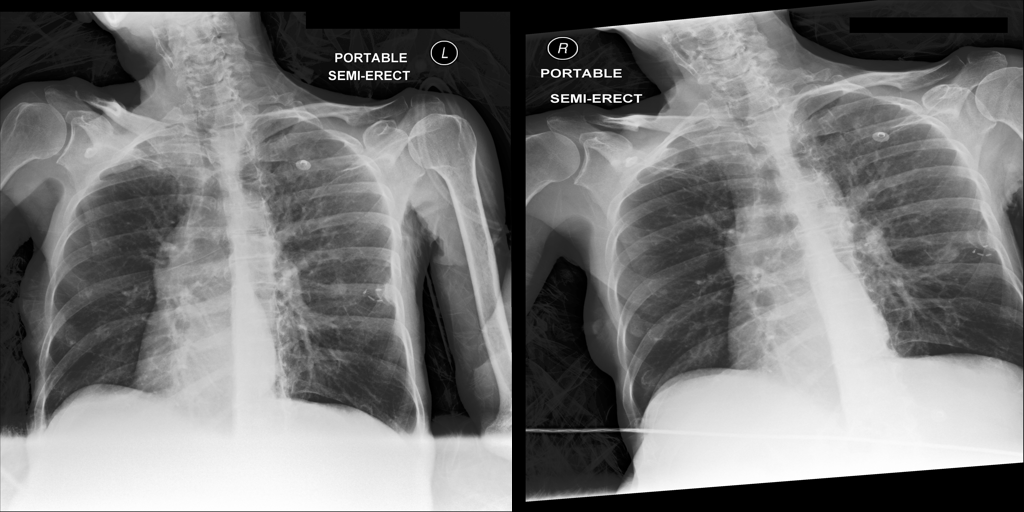

In [31]:
show_imgs('/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762')

### Saving size test

In [32]:
os.listdir('/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762')

['index.html',
 '68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg',
 'fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg']

In [ ]:
def get_file_size(file_path):
    size = os.path.getsize(file_path)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if size < 1024:
            return f"{size:.2f} {unit}"
        size /= 1024



File size: 1.34 MB


In [ ]:
file_path = "/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg"
print(f"Original jpg size: {os.path.getsize(file_path)/1024/1024:.2f} MB")

def resize_pil_png(path):
    image = Image.open(path)

    # Resize the image to 512x512
    resized_image = image.resize((512, 512))

    # Save as PNG
    output_path = "temp/output_jpg.png"
    resized_image.save(output_path)
    print(f"Resized png size: {os.path.getsize(output_path)/1024/1024:.2f} MB")

def resize_pil_jpg(path):
    image = Image.open(path)

    # Resize the image to 512x512
    resized_image = image.resize((512, 512))

    # Save as PNG
    output_path = "temp/output_jpg.jpg"
    resized_image.save(output_path)
    print(f"Resized jpg size: {os.path.getsize(output_path)/1024/1024:.2f} MB")

resize_pil_png(file_path)
resize_pil_jpg(file_path)


Original jpg size: 1.34 MB
Resized png size: 0.12 MB
Resized jpg size: 0.03 MB


resized to png | resized to jpg


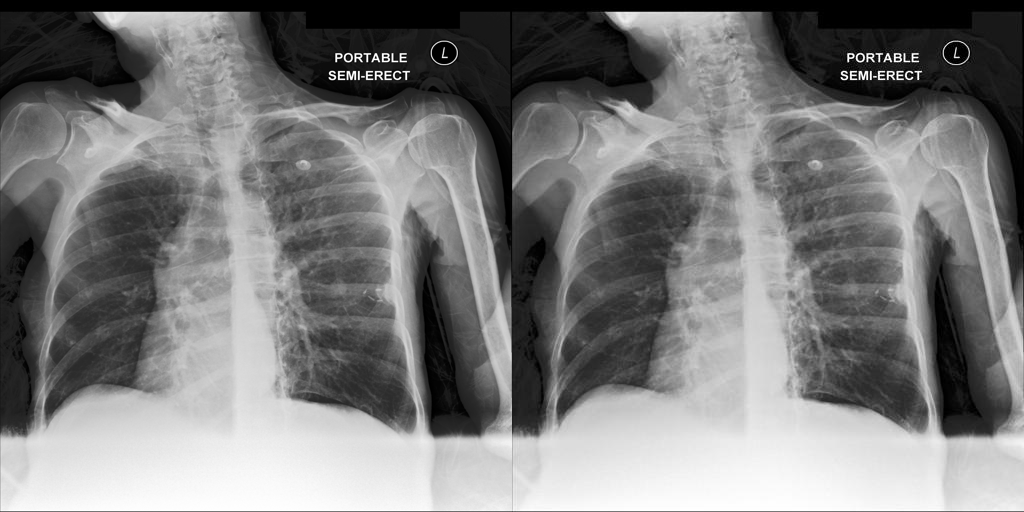

In [40]:
# Compare
imgs = []

imgs.append(Image.open("temp/output_jpg.png"))
imgs.append(Image.open("temp/output_jpg.jpg"))

print('resized to png | resized to jpg')
concat(imgs)

In [42]:
def resize_pil_png(path):
    image = Image.open(path)

    # Resize the image to 512x512
    resized_image = image.resize((512, 512))

    # Save as PNG
    output_path = "temp/output_jpg.png"
    resized_image.save(output_path)

In [53]:
%%timeit 10 
resize_pil_png(file_path)

67.3 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [54]:
def resize_pil_jpg(path):
    image = Image.open(path)

    # Resize the image to 512x512
    resized_image = image.resize((512, 512))

    # Save as PNG
    output_path = "temp/output_jpg.jpg"
    resized_image.save(output_path)

In [55]:
%%timeit 10 
resize_pil_jpg(file_path)

33.4 ms ± 1.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [56]:
total_png_ms = 67.3 * 37000
print(f'Total hours processing to png: {total_png_ms/1000/60/60}')

Total hours processing to png: 0.6916944444444444


In [57]:
from PIL import Image, ImageOps
import os

def resize_and_crop(image_path, output_path):
    """Resizes and center-crops an image to 512x512 pixels with black padding if needed."""
    img = Image.open(image_path).convert("RGB")

    # Step 1: Resize while preserving aspect ratio
    max_size = 512
    img.thumbnail((max_size, max_size), Image.LANCZOS)

    # Step 2: Create a black square canvas and paste the resized image at the center
    new_img = Image.new("RGB", (512, 512), (0, 0, 0))  # Black background
    x_offset = (512 - img.size[0]) // 2
    y_offset = (512 - img.size[1]) // 2
    new_img.paste(img, (x_offset, y_offset))

    # Save the processed image
    new_img.save(output_path, format="JPEG")

def process_images(image_list, output_dir):
    """Processes a list of images and saves them to the output directory."""
    os.makedirs(output_dir, exist_ok=True)
    
    for image_path in image_list:
        filename = os.path.basename(image_path)
        output_path = os.path.join(output_dir, filename)
        resize_and_crop(image_path, output_path)
        print(f"Processed: {filename} -> {output_path}")

# # Example usage
# image_list = ["image1.jpg", "image2.jpg", "image3.jpg"]  # Replace with actual paths
# output_dir = "processed_images"
# process_images(image_list, output_dir)

In [63]:
import cv2
import numpy as np
import os

def resize_and_pad(image_path, output_path):
    """Resizes an image to a maximum of 512 pixels on the longest side, 
    then centers it on a 512x512 black canvas (padding if needed)."""
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return

    h, w = img.shape[:2]
    max_size = 512

    # Step 1: Resize while keeping aspect ratio
    scale = max_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    

    plt.figure(figsize=(6,6))
    plt.imshow(resized_img, cmap='gray')  # Show in grayscale
    plt.axis('off')  # Hide axes
    plt.show()

    # Step 2: Create a black 512x512 canvas and paste the resized image at the center
    padded_img = np.zeros((512, 512, 3), dtype=np.uint8)  # Black canvas
    x_offset = (512 - new_w) // 2
    y_offset = (512 - new_h) // 2
    padded_img[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_img
    
    plt.figure(figsize=(6,6))
    plt.imshow(padded_img, cmap='gray')  # Show in grayscale
    plt.axis('off')  # Hide axes
    plt.show()

    # Save the processed image
    cv2.imwrite(output_path, padded_img)
    print(f"Processed: {output_path}")

def process_images(image_list, output_dir):
    """Processes a list of images and saves them to the output directory."""
    os.makedirs(output_dir, exist_ok=True)
    
    for image_path in image_list:
        filename = os.path.basename(image_path)
        output_path = os.path.join(output_dir, filename)
        resize_and_pad(image_path, output_path)

# Example usage
# image_list = ["image1.jpg", "image2.jpg", "image3.jpg"]  # Replace with actual paths
# output_dir = "processed_images"
# process_images(image_list, output_dir)

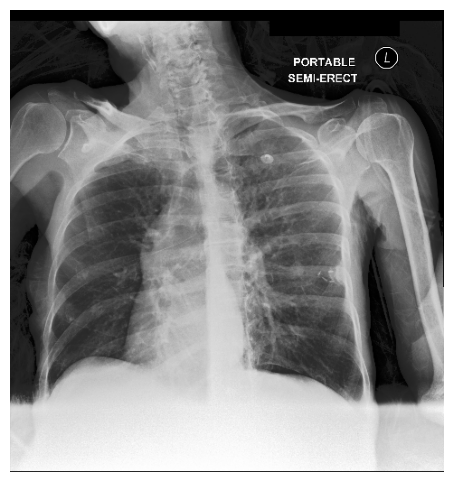

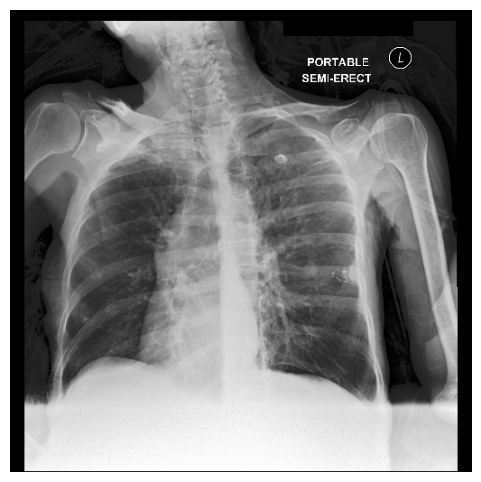

Processed: temp/processed_opencv.png


In [64]:
file_path = "/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg"
output_path = 'temp/processed_opencv.png'

resize_and_pad(file_path, output_path)


In [62]:
%%timeit 10
file_path = "/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg"
output_path = 'temp/processed_opencv.png'

resize_and_pad(file_path, output_path)

Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
Processed: temp/processed_opencv.png
P

In [60]:
file_path = "/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg"
output_path = 'temp/processed_pil.png'

resize_and_crop(file_path, output_path)

In [61]:
%%timeit 10

file_path = "/Users/juanpablomeli/Documents/personal/Tesis/MIMIC-CXR/MIMIC-CXR-JPG/p10/p10000032/s53911762/68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg"
output_path = 'temp/processed_pil.png'

resize_and_crop(file_path, output_path)

52.6 ms ± 1.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
